# 01 — Are VGG features actually Gaussian?

Gatys / AdaIN / WCT all match either the Gram matrix or the mean+std of VGG feature activations. That is only *fully* justified if the underlying per-channel distributions are Gaussian — a Gaussian is completely determined by its first two moments, so matching them matches the whole distribution.

This notebook checks that empirically. Post-ReLU activations are non-negative and sparse, so the assumption is *a priori* suspect. We measure it directly.

**Setup**: Runtime → Change runtime type → GPU (T4 is fine). Upload a `style.jpg` in the file browser on the left (or use the wget cell below).

In [1]:
# Colab already has torch, torchvision, matplotlib, scipy. Nothing to install.
import torch, torch.nn as nn
import torchvision.models as tvm
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
torch.manual_seed(0); np.random.seed(0)

device: cuda


In [2]:
# Grab a sample style image if you haven't uploaded one. Replace the URL / path as needed.
import os
if not os.path.exists('style.jpg'):
    !wget -q -O style.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1024px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg
print('style.jpg size:', os.path.getsize('style.jpg'), 'bytes')

style.jpg size: 0 bytes


## VGG feature extractor at the classical Gatys layers

torchvision VGG19 layer indices:
- `1 = relu1_1`, `6 = relu2_1`, `11 = relu3_1`, `20 = relu4_1`, `29 = relu5_1`

These are exactly the five layers Gatys uses for the style loss.

In [4]:
class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = tvm.vgg19(weights=tvm.VGG19_Weights.IMAGENET1K_V1).features.eval()
        self.layer_ids = {'relu1_1': 1, 'relu2_1': 6, 'relu3_1': 11,
                          'relu4_1': 20, 'relu5_1': 29}
        self.vgg = vgg
        for p in self.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        feats, last = {}, max(self.layer_ids.values())
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            for name, idx in self.layer_ids.items():
                if i == idx:
                    feats[name] = x
            if i >= last:
                break
        return feats

def load_image(path, size=512):
    tf = T.Compose([
        T.Resize(size), T.CenterCrop(size),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return tf(Image.open(path).convert('RGB')).unsqueeze(0).to(device)

vgg = VGGFeatures().to(device)
style = load_image('/content/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg')
with torch.no_grad():
    feats = vgg(style)
for k, v in feats.items():
    print(f'{k:10s} shape={tuple(v.shape)}')

relu1_1    shape=(1, 64, 512, 512)
relu2_1    shape=(1, 128, 256, 256)
relu3_1    shape=(1, 256, 128, 128)
relu4_1    shape=(1, 512, 64, 64)
relu5_1    shape=(1, 512, 32, 32)


## Per-channel Gaussianity report

For each layer, each channel is a scalar random variable with `H*W` samples. We compute:

- **`zeros`**: fraction of exactly-zero activations. Post-ReLU. A Gaussian has zero probability mass at exactly 0. Anything above ~1% already breaks the assumption.
- **`|skew|`**: absolute skewness. Gaussian = 0.
- **`kurt`**: excess kurtosis. Gaussian = 0. Positive = heavy tails.
- **`%chan Gaussian`**: fraction of channels where D'Agostino's K² test fails to reject Gaussianity at p > 0.05. Generous threshold — with thousands of samples the test rejects easily. Anything near 0% means "no channel looks Gaussian."

In [5]:
def gaussianity_report(feats_dict, n_samples=5000):
    out = {}
    for name, f in feats_dict.items():
        C = f.shape[1]
        flat = f.reshape(C, -1).cpu().numpy()
        idx = np.random.choice(flat.shape[1],
                               min(n_samples, flat.shape[1]), replace=False)
        sub = flat[:, idx]
        zero_frac = (flat == 0).mean(axis=1)
        skewness = stats.skew(sub, axis=1)
        kurt = stats.kurtosis(sub, axis=1)
        p = np.array([stats.normaltest(sub[c]).pvalue for c in range(C)])
        out[name] = dict(zeros=zero_frac.mean(),
                         abs_skew=np.abs(skewness).mean(),
                         kurt=kurt.mean(),
                         frac_gaussian=(p > 0.05).mean())
    return out

rep = gaussianity_report(feats)
print(f"{'layer':10s} {'mean_zeros':>10s} {'|skew|':>8s} {'kurt':>8s} {'%chan Gaussian':>16s}")
print('-' * 55)
for l, r in rep.items():
    print(f"{l:10s} {r['zeros']:>10.2f} {r['abs_skew']:>8.2f} "
          f"{r['kurt']:>8.2f} {100*r['frac_gaussian']:>15.1f}%")

layer      mean_zeros   |skew|     kurt   %chan Gaussian
-------------------------------------------------------
relu1_1          0.37     2.06    10.87             0.0%
relu2_1          0.62      nan      nan             0.0%
relu3_1          0.68     3.42    24.49             0.0%
relu4_1          0.81     4.99    39.51             0.0%
relu5_1          0.78     4.86    37.20             0.0%


## The visual proof — per-channel histograms vs Gaussian fit

Pick the three highest-variance channels at each layer and overlay a Gaussian fit. The mass-at-zero spike from ReLU should be dramatically visible and will not sit under the red curve. If the assumption held, red and blue would agree.

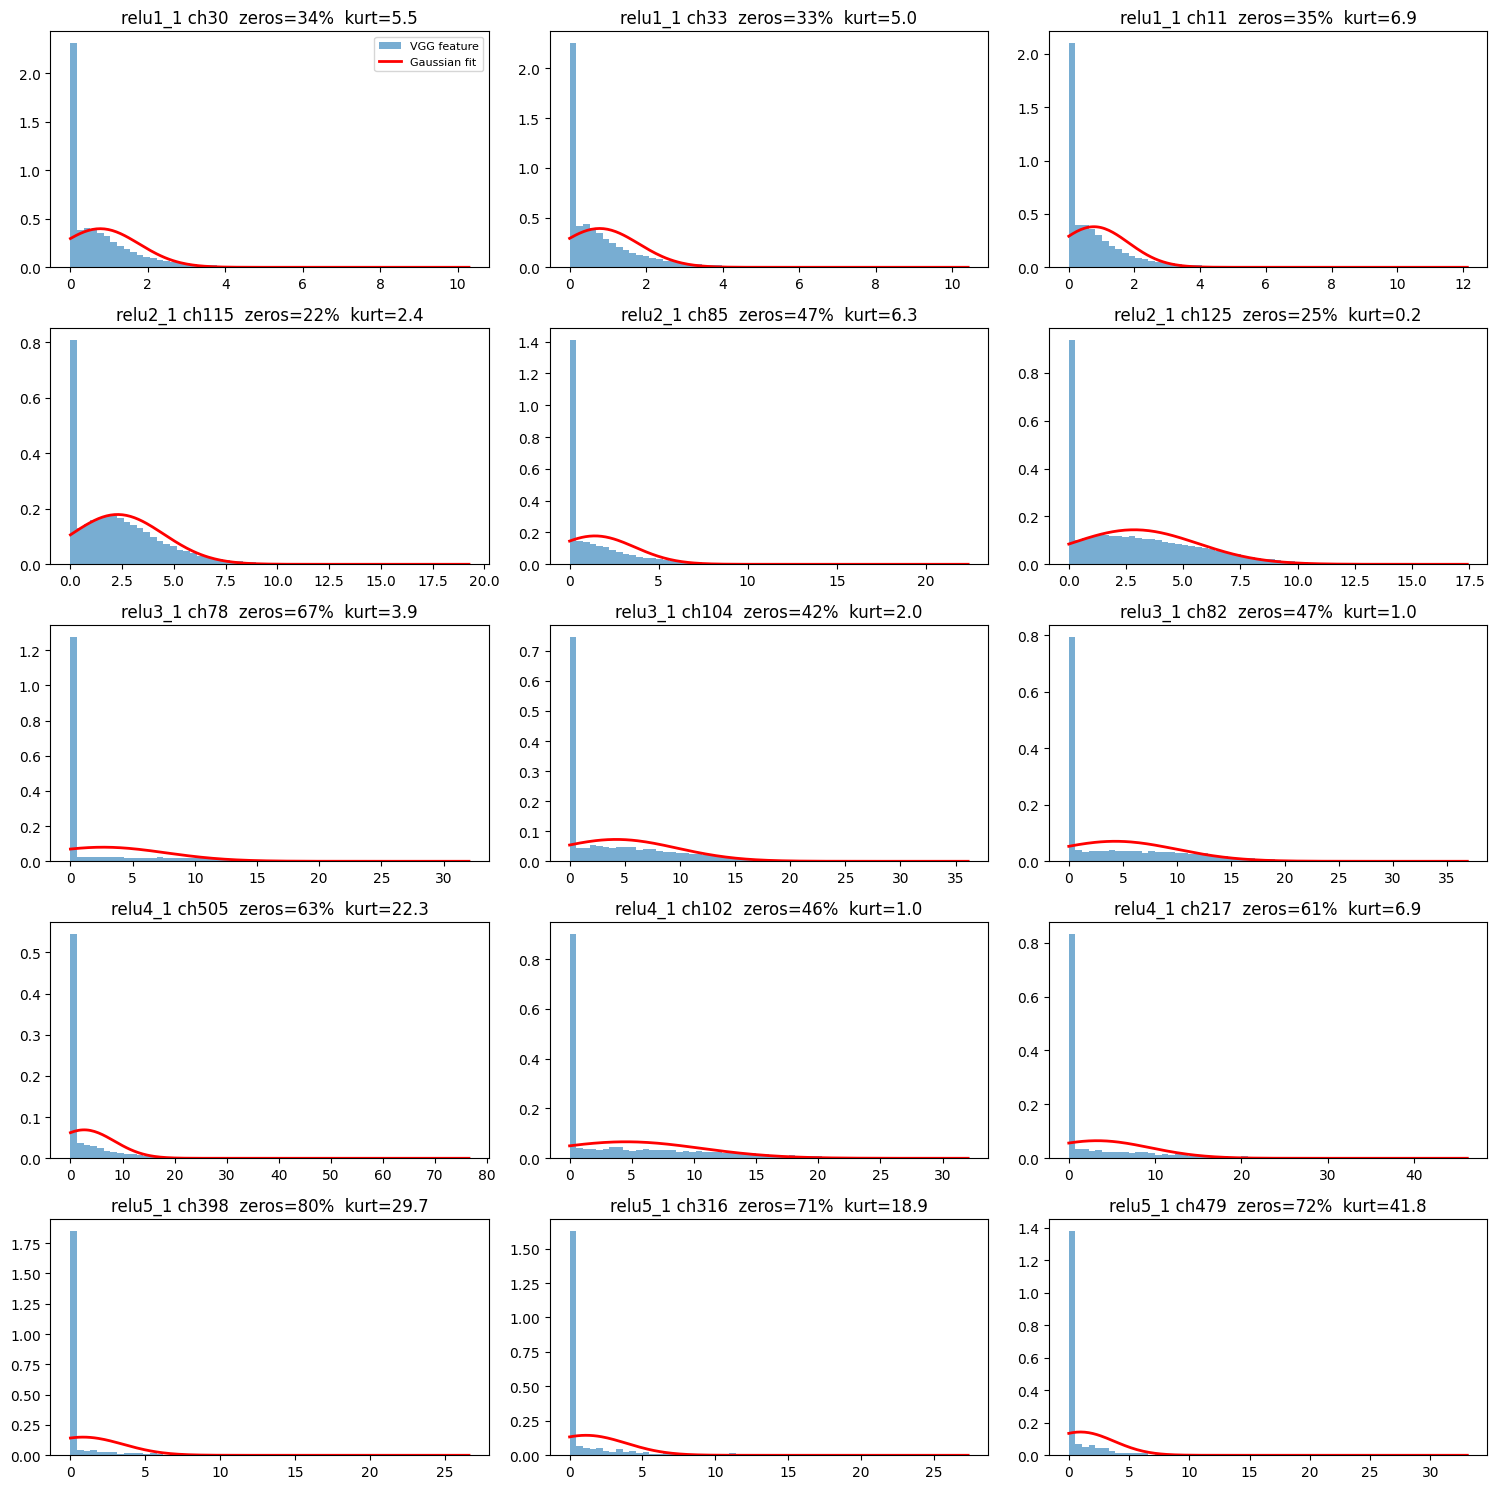

In [6]:
layers = list(feats.keys())
fig, ax = plt.subplots(len(layers), 3, figsize=(15, 3 * len(layers)))
for row, l in enumerate(layers):
    f = feats[l].reshape(feats[l].shape[1], -1).cpu().numpy()
    top = np.argsort(f.var(axis=1))[-3:]
    for col, c in enumerate(top):
        v = f[c]
        a = ax[row, col]
        a.hist(v, bins=60, density=True, alpha=0.6, label='VGG feature')
        xs = np.linspace(v.min(), v.max(), 200)
        a.plot(xs, stats.norm.pdf(xs, v.mean(), v.std()), 'r-', lw=2, label='Gaussian fit')
        a.set_title(f'{l} ch{c}  zeros={100*(v==0).mean():.0f}%  kurt={stats.kurtosis(v):.1f}')
        if row == 0 and col == 0:
            a.legend(fontsize=8)
plt.tight_layout()
plt.savefig('gaussianity.png', dpi=120)
plt.show()

## How to read this

If `%chan Gaussian` is near 0% across all layers, and the histograms show a big spike at zero plus heavy right tails, then the whole "match 1st + 2nd moment" logic of Gatys/AdaIN is throwing away real distributional information. That's the concrete empirical hook for the argument.

Notebook 02 tests whether that missing information *matters visually* by comparing against a sliced-Wasserstein loss that matches the full distribution.